In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error
from data_functions import *

In [72]:
PROJECT_ROOT = Path.cwd().parent

PATHS = {
    # Метки
    "train_labels": PROJECT_ROOT / "dataset" / "labels" / "labels_train.csv",
    "test_labels": PROJECT_ROOT / "dataset" / "labels" / "labels_test.csv",
    
    # Обучающая и тестовая телематика/расписание
    "train_traffic": PROJECT_ROOT / "dataset" / "train" / "traffic.csv",
    "train_schedule": PROJECT_ROOT / "dataset" / "train" / "schedule.csv",
    "test_traffic": PROJECT_ROOT / "dataset" / "test" / "traffic.csv",
    "test_schedule": PROJECT_ROOT / "dataset" / "test" / "schedule.csv",
    
    # Валидация (финальный инференс)
    "val_points": PROJECT_ROOT / "dataset" / "validate" / "points.csv",
    "val_traffic": PROJECT_ROOT / "dataset" / "validate" / "traffic.csv",
    "val_schedule_plan": PROJECT_ROOT / "dataset" / "validate" / "schedule_plan.csv",
    
    # Сабмит
    "sample_submission": PROJECT_ROOT / "dataset" / "sample_submission.csv",
    "output_submission": PROJECT_ROOT / "submission.csv",
}

In [73]:
train_traffic = load_and_preprocess_traffic(PATHS["train_traffic"])
train_labels = load_and_preprocess_labels(PATHS["train_labels"])
train_schedule = load_and_preprocess_schedule(PATHS["train_schedule"])

# 2. Считаем статистики расписания по train
schedule_features = compute_schedule_features(train_schedule)

# 3. Собираем обучающий датасет
train_data_full = build_dataset(train_labels, train_traffic, schedule_features)

In [74]:
train_data_full.head(3)
# location_valid - достоверность по GPS

,sample_id,tr_id,T,target_stop_id,target_time_begin,cur_dev_s,target_delay_s,target_class,is_late_now,abs_cur_dev_s,...,sched_std_delay,sched_max_delay,speed,is_standing,speed_diff,heading,alt,gps_failure,telemetry_age_s,telemetry_missing
0,122048_1767665400,122048,2026-01-06 02:10:00,53699018679,2026-01-06 02:22:00.000000000,0.0,-25.0,ontime,0,0.0,...,159.163558,607.0,0.0,1.0,0.0,38.0,175.0,0.0,8.000000,0
1,9000014_1767665400,9000014,2026-01-06 02:10:00,10400473,2026-01-06 02:20:56.876587200,0.0,7.0,ontime,0,0.0,...,141.520859,506.0,0.0,1.0,0.0,0.0,0.0,1.0,2.123413,0
2,9000001_1767665400,9000001,2026-01-06 02:10:00,9100456,2026-01-06 02:23:06.862763477,0.0,31.0,ontime,0,0.0,...,161.427802,592.0,0.0,1.0,-1.0,81.0,175.0,0.0,1.137237,0


<Axes: xlabel='lon', ylabel='lat'>

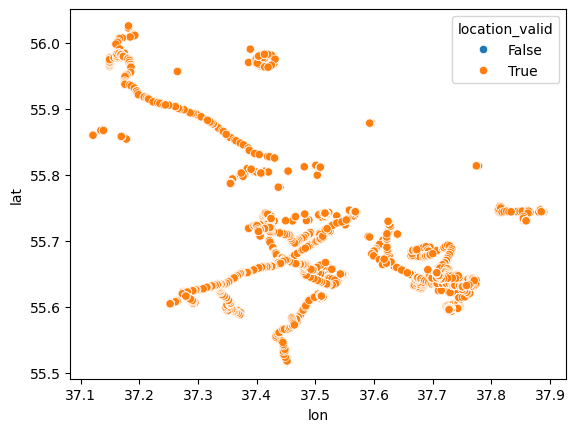

In [75]:
sns.scatterplot(data=train_traffic[train_traffic["speed"] == 0], x="lon", y="lat", hue="location_valid")

In [76]:
train_data_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4434 entries, 0 to 4433
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   sample_id           4434 non-null   object        
 1   tr_id               4434 non-null   int64         
 2   T                   4434 non-null   datetime64[ns]
 3   target_stop_id      4434 non-null   int64         
 4   target_time_begin   4434 non-null   datetime64[ns]
 5   cur_dev_s           4434 non-null   float64       
 6   target_delay_s      4434 non-null   float64       
 7   target_class        4434 non-null   object        
 8   is_late_now         4434 non-null   int64         
 9   abs_cur_dev_s       4434 non-null   float64       
 10  is_ontime_now       4434 non-null   int64         
 11  time_to_target_s    4434 non-null   float64       
 12  hour                4434 non-null   int32         
 13  minute              4434 non-null   int32       

In [77]:
train_data_full.describe()
# выводs: 
# device_event_id - мусорный признак ===УДАЛИЛИ===
# в lon, lat, alt есть 0.0 - с этим нужно что-то делать ===Интерполяция===
# выбросы в alt, speed - нужно решить, что с этим делать. скорее всего это сбой GPS. можно клипнуть / приравнять к соседним или среднему. ===ОТСЕКЛИ (0,110)===
# данные только 2026-01-06. НУЖНО БЫТЬ АККУРАТНО С ВРЕМЕНЕМ, МОЖНО УТЕЧЬ

,tr_id,T,target_stop_id,target_time_begin,cur_dev_s,target_delay_s,is_late_now,abs_cur_dev_s,is_ontime_now,time_to_target_s,...,sched_std_delay,sched_max_delay,speed,is_standing,speed_diff,heading,alt,gps_failure,telemetry_age_s,telemetry_missing
count,4.434000e+03,4434,4.434000e+03,4434,4434.000000,4434.000000,4434.00000,4434.000000,4434.000000,4434.000000,...,4434.000000,4434.000000,4434.000000,4434.000000,4434.000000,4434.000000,4434.000000,4434.000000,4434.000000,4434.000000
mean,6.717531e+06,2026-01-06 12:22:47.320703744,1.382691e+10,2026-01-06 12:34:00.378646528,54.752594,48.889716,0.60442,98.793640,0.473613,673.057943,...,122.287436,438.435273,14.087596,0.410014,0.683311,142.519621,179.526613,0.140054,7.206177,0.000226
min,1.220480e+05,2026-01-06 02:10:00,9.000001e+06,2026-01-06 02:20:56.876587200,-404.000000,-372.000000,0.00000,0.000000,0.000000,603.094276,...,0.000000,0.000000,0.000000,0.000000,-20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.350810e+05,2026-01-06 07:35:00,9.800025e+06,2026-01-06 07:46:00,-19.000000,-25.000000,0.00000,23.000000,0.000000,632.630011,...,99.868293,332.000000,0.000000,0.000000,-2.000000,32.000000,125.000000,0.000000,2.000000,0.000000
50%,9.000007e+06,2026-01-06 12:20:00,1.070026e+07,2026-01-06 12:30:23.701339648,26.000000,24.000000,1.00000,65.000000,0.000000,660.000000,...,125.585455,433.000000,7.700000,0.000000,0.000000,127.500000,151.000000,0.000000,5.000000,0.000000
75%,9.000017e+06,2026-01-06 16:45:00,5.369833e+10,2026-01-06 16:56:17.928806912,115.000000,107.000000,1.00000,140.000000,1.000000,702.880134,...,153.002047,592.000000,23.000000,1.000000,3.200000,236.000000,179.000000,0.000000,9.000000,0.000000
max,9.000025e+06,2026-01-07 00:25:00,5.372148e+10,2026-01-07 00:35:10.268893882,661.000000,672.000000,1.00000,661.000000,1.000000,900.000000,...,163.210209,685.000000,110.000000,1.000000,20.000000,359.000000,65505.000000,1.000000,999.000000,1.000000
std,3.878014e+06,NaN,2.347498e+10,NaN,132.092766,131.223838,0.48903,103.366516,0.499360,56.892806,...,32.011525,147.839188,18.690186,0.491891,8.648707,114.511933,991.852282,0.347082,22.302481,0.015018


<Axes: ylabel='speed'>

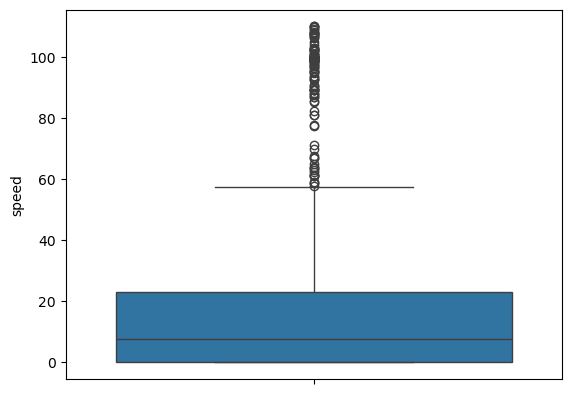

In [78]:
sns.boxplot(data=train_data_full["speed"])
# слишком много плохих значений. нужно проверить, связано ли это с location_valid (сделать признак?) ===

In [79]:
train_data_full.nunique()
# вывод: device_event_id - мусорный признак, всего одно значение - 0. ===ДРОПНУЛИ===

sample_id             4434
tr_id                   39
T                      268
target_stop_id        4434
target_time_begin     3834
cur_dev_s              657
target_delay_s         690
target_class             3
is_late_now              2
abs_cur_dev_s          426
is_ontime_now            2
time_to_target_s       127
hour                    23
minute                  12
minute_of_day          268
sin_time               240
cos_time               250
is_morning_peak          2
is_evening_peak          2
sched_mean_delay        39
sched_median_delay      25
sched_std_delay         39
sched_max_delay         39
speed                  564
is_standing              2
speed_diff             892
heading                357
alt                    255
gps_failure              2
telemetry_age_s        637
telemetry_missing        2
dtype: int64

In [80]:
train_data_full.isna().sum()
# херово, в некоторых местах нет данных. варианты: среднее между соседними, может по расстоянию/время. ===интерполировали признак между соседними точками===


#  FEATURE_ENGINEERING traffic
# gps_failure / lon, lat, alt == NaN
# delay / time_begin - time_fact_begin

sample_id             0
tr_id                 0
T                     0
target_stop_id        0
target_time_begin     0
cur_dev_s             0
target_delay_s        0
target_class          0
is_late_now           0
abs_cur_dev_s         0
is_ontime_now         0
time_to_target_s      0
hour                  0
minute                0
minute_of_day         0
sin_time              0
cos_time              0
is_morning_peak       0
is_evening_peak       0
sched_mean_delay      0
sched_median_delay    0
sched_std_delay       0
sched_max_delay       0
speed                 0
is_standing           0
speed_diff            0
heading               0
alt                   0
gps_failure           0
telemetry_age_s       0
telemetry_missing     0
dtype: int64

In [81]:
train_schedule.head(3)

,tt_action_item_id,time_begin,time_fact_begin,manual_fill,tr_id,geom
0,53699433970,2026-01-06 06:36:00,2026-01-06 06:39:01,True,122658,POINT (37.43070705 55.8040083)
1,53699433974,2026-01-06 06:41:00,2026-01-06 06:44:01,True,122658,POINT (37.46330869 55.80892705)
2,53699433972,2026-01-06 06:38:00,2026-01-06 06:41:01,True,122658,POINT (37.45439344 55.80550491)


In [82]:
train_schedule.describe()

,tt_action_item_id,time_begin,time_fact_begin,tr_id
count,1.667400e+04,16674,16674,1.667400e+04
mean,1.790807e+10,2026-01-06 13:13:36.753878784,2026-01-06 13:14:29.144186880,6.043487e+06
min,9.000000e+06,2026-01-06 02:11:56.876587200,2026-01-06 02:12:06.876587200,1.220480e+05
25%,1.010005e+07,2026-01-06 07:52:27.263508224,2026-01-06 07:54:08.986426624,1.339570e+05
50%,1.090037e+07,2026-01-06 12:54:49.253432320,2026-01-06 12:55:55.815005696,9.000006e+06
75%,5.369855e+10,2026-01-06 17:57:57.844343808,2026-01-06 17:59:04.424280320,9.000016e+06
max,5.372148e+10,2026-01-07 04:21:00,2026-01-07 04:21:00,9.000025e+06
std,2.531207e+10,NaN,NaN,4.181284e+06


In [83]:
train_schedule.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16674 entries, 0 to 16673
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   tt_action_item_id  16674 non-null  int64         
 1   time_begin         16674 non-null  datetime64[ns]
 2   time_fact_begin    16674 non-null  datetime64[ns]
 3   manual_fill        16674 non-null  bool          
 4   tr_id              16674 non-null  int64         
 5   geom               16674 non-null  object        
dtypes: bool(1), datetime64[ns](2), int64(2), object(1)
memory usage: 667.7+ KB


In [84]:
train_schedule.nunique()
# order_date всего одно значение. ===ДРОПНУЛИ===

tt_action_item_id    16674
time_begin           12237
time_fact_begin      16342
manual_fill              2
tr_id                   39
geom                   847
dtype: int64

In [85]:
train_schedule.isna().sum()
# building_address местами пустует. в дальнейшем он не нужен будет, наверное. нахер его ===ДРОПНУЛИ===

tt_action_item_id    0
time_begin           0
time_fact_begin      0
manual_fill          0
tr_id                0
geom                 0
dtype: int64

In [86]:
train_labels.head(3)

,sample_id,tr_id,T,target_stop_id,target_time_begin,cur_dev_s,target_delay_s,target_class,is_late_now,abs_cur_dev_s,is_ontime_now,time_to_target_s,hour,minute,minute_of_day,sin_time,cos_time,is_morning_peak,is_evening_peak
0,122048_1767665400,122048,2026-01-06 02:10:00,53699018679,2026-01-06 02:22:00,0.0,-25.0,ontime,0,0.0,1,720.0,2,10,130,0.537300,0.843391,0,0
1,122048_1767665700,122048,2026-01-06 02:15:00,53699018678,2026-01-06 02:26:00,0.0,0.0,ontime,0,0.0,1,660.0,2,15,135,0.555570,0.831470,0,0
2,122048_1767666000,122048,2026-01-06 02:20:00,53699018687,2026-01-06 02:32:00,0.0,0.0,ontime,0,0.0,1,720.0,2,20,140,0.573576,0.819152,0,0


In [87]:
train_labels.info()
#  FEATURE_ENGINEERING labels
# is_late - опаздывает или нет cur_dev_s == 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4434 entries, 0 to 4433
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sample_id          4434 non-null   object        
 1   tr_id              4434 non-null   int64         
 2   T                  4434 non-null   datetime64[ns]
 3   target_stop_id     4434 non-null   int64         
 4   target_time_begin  4434 non-null   datetime64[ns]
 5   cur_dev_s          4434 non-null   float64       
 6   target_delay_s     4434 non-null   float64       
 7   target_class       4434 non-null   object        
 8   is_late_now        4434 non-null   int64         
 9   abs_cur_dev_s      4434 non-null   float64       
 10  is_ontime_now      4434 non-null   int64         
 11  time_to_target_s   4434 non-null   float64       
 12  hour               4434 non-null   int32         
 13  minute             4434 non-null   int32         
 14  minute_o

In [88]:
train_labels.describe()
# cur_dev_s очень сильно коррелирует с target_delay_s. сделаем бейзлайн с cur_dev_s
# бля, я его сделал, а оказалось что у оргов такой же сабмит хахаххахахахах

,tr_id,T,target_stop_id,target_time_begin,cur_dev_s,target_delay_s,is_late_now,abs_cur_dev_s,is_ontime_now,time_to_target_s,hour,minute,minute_of_day,sin_time,cos_time,is_morning_peak,is_evening_peak
count,4.434000e+03,4434,4.434000e+03,4434,4434.000000,4434.000000,4434.00000,4434.000000,4434.000000,4434.000000,4434.000000,4434.00000,4434.000000,4434.000000,4434.000000,4434.000000,4434.000000
mean,6.717531e+06,2026-01-06 12:22:47.320703744,1.382691e+10,2026-01-06 12:34:00.378646528,54.752594,48.889716,0.60442,98.793640,0.473613,673.057943,11.861299,27.53834,739.216283,0.007278,-0.236877,0.206360,0.153811
min,1.220480e+05,2026-01-06 02:10:00,9.000001e+06,2026-01-06 02:20:56.876587200,-404.000000,-372.000000,0.00000,0.000000,0.000000,603.094276,0.000000,0.00000,0.000000,-1.000000,-1.000000,0.000000,0.000000
25%,1.350810e+05,2026-01-06 07:35:00,9.800025e+06,2026-01-06 07:46:00,-19.000000,-25.000000,0.00000,23.000000,0.000000,632.630011,7.000000,15.00000,455.000000,-0.737277,-0.831470,0.000000,0.000000
50%,9.000007e+06,2026-01-06 12:20:00,1.070026e+07,2026-01-06 12:30:23.701339648,26.000000,24.000000,1.00000,65.000000,0.000000,660.000000,12.000000,30.00000,735.000000,-0.065403,-0.362438,0.000000,0.000000
75%,9.000017e+06,2026-01-06 16:45:00,5.369833e+10,2026-01-06 16:56:17.928806912,115.000000,107.000000,1.00000,140.000000,1.000000,702.880134,16.000000,45.00000,1000.000000,0.806445,0.321439,0.000000,0.000000
max,9.000025e+06,2026-01-07 00:25:00,5.372148e+10,2026-01-07 00:35:10.268893882,661.000000,672.000000,1.00000,661.000000,1.000000,900.000000,23.000000,55.00000,1435.000000,1.000000,1.000000,1.000000,1.000000
std,3.878014e+06,NaN,2.347498e+10,NaN,132.092766,131.223838,0.48903,103.366516,0.499360,56.892806,5.691079,17.26576,340.824147,0.739766,0.629918,0.404738,0.360809


In [89]:
train_labels.isna().sum()

sample_id            0
tr_id                0
T                    0
target_stop_id       0
target_time_begin    0
cur_dev_s            0
target_delay_s       0
target_class         0
is_late_now          0
abs_cur_dev_s        0
is_ontime_now        0
time_to_target_s     0
hour                 0
minute               0
minute_of_day        0
sin_time             0
cos_time             0
is_morning_peak      0
is_evening_peak      0
dtype: int64

<Axes: xlabel='target_delay_s', ylabel='Count'>

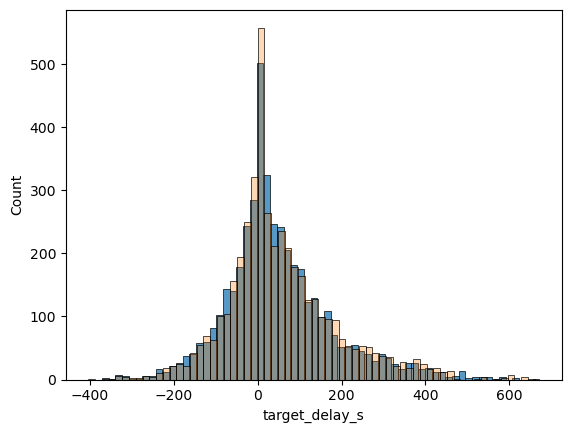

In [90]:
sns.histplot(data=train_labels["target_delay_s"])
sns.histplot(data=train_labels["cur_dev_s"], alpha=0.3)
# jackpot - нормальное распределение

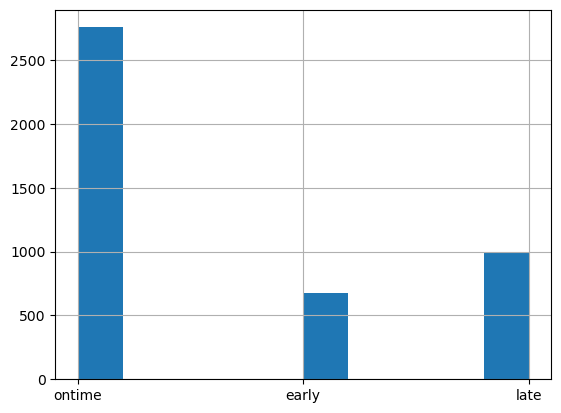

In [91]:
data=train_labels["target_class"].hist()